In [1]:
import functools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import optimize

 - https://stackoverflow.com/questions/79720948/solve-a-2-equations-systems-of-quadratic-equations-with-2-unknows

In [2]:
class PhotoSonicSolver:

    def __init__(self, a):
        self._a = np.array(a)

    @property
    def n(self):
        return self._a.shape[0]
    
    @staticmethod
    def base_model(x, a):
        return a[0] + a[1] * x[0] + a[2] * x[1] + a[3] * x[0] * x[1] + a[4] * x[0] ** 2 + a[5] * x[1] ** 2

    def model_factory(self, i):
        return functools.partial(self.base_model, a=self._a[i,:])

    def residuals(self, x, signals):
        return np.array([self.model_factory(i)(x) - signals[i] for i in range(self.n)])

    def objective(self, x, signals):
        return np.sum(self.residuals(x, signals) ** 2)

    def solve(self, signals, x0=None, tol=1e-12):
        return optimize.minimize(solver.objective, x0=x0, args=signals, tol=tol).x

    def signals(self, x):
        return solver.residuals(x.T, signals=[0] * self.n).T

    def measurands(self, g, x0=None):
        return np.apply_along_axis(self.solve, 1, g, x0=x0)

In [3]:
solver = PhotoSonicSolver([
    [+2.210e-04, +6.071e-07, -1.942e-05, +9.131e-08, +1.258e-10, +2.269e-07], # Real sensor 1
    [-2.658e-04, +4.486e-06, +1.824e-05, +4.013e-07, +1.767e-11, -2.623e-07], # Real sensor 2
    #[+3.012e-04, +5.897e-06, -2.098e-05, +7.987e-07, +4.567e-11, +3.011e-07], # Fake sensor 3
])

In [4]:
x0s = np.array([
    [+0, +0],
    [+0, +100],
    [+400, +0],
    [+400, +100],
])

In [5]:
signals = solver.residuals([400, 30], [0] * solver.n)
signals

array([0.0012013 , 0.00665816])

In [6]:
solver.solve(signals, x0=[400, 100])

array([399.99902948,  30.0000896 ])

In [7]:
x0lin = np.linspace(400, 1000, 200)
x1lin = np.linspace(80, 20, 200)

In [8]:
x = np.array([x0lin, x1lin]).T

In [9]:
g = solver.signals(x)

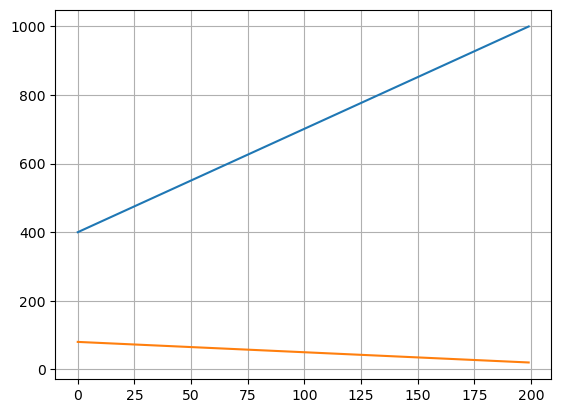

In [10]:
fig, axe = plt.subplots()
axe.plot(x)
axe.grid()

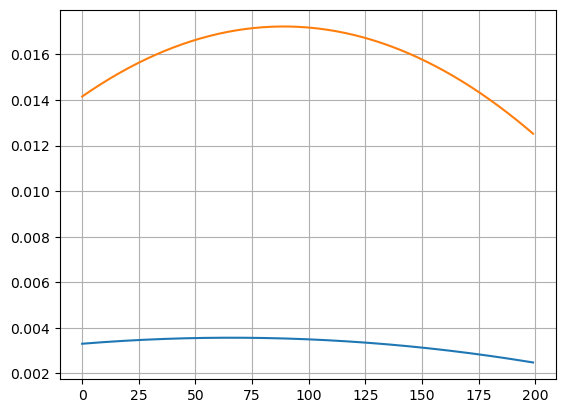

In [11]:
fig, axe = plt.subplots()
axe.plot(g)
axe.grid()

In [12]:
x_reg = solver.measurands(g, x0=[600, 50])

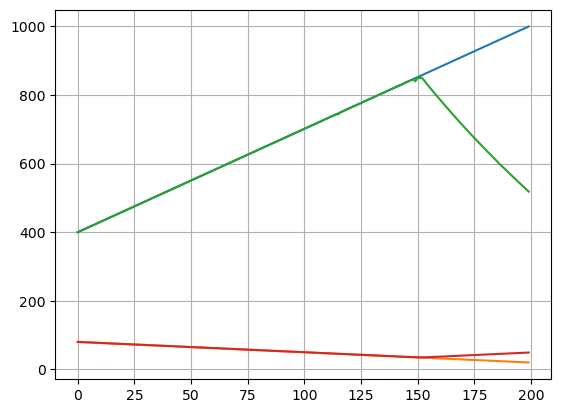

In [13]:
fig, axe = plt.subplots()
axe.plot(x)
axe.plot(x_reg)
axe.grid()

In [14]:
data1 = pd.read_csv("first_signal.csv").drop("Unnamed: 0", axis=1).set_index("time (s)").rename(columns={"Signal (V)": "g1"})
data2 = pd.read_csv("second_signal.csv").drop("Unnamed: 0", axis=1).set_index("time (s)").rename(columns={"Signal (V)": "g2"})

In [15]:
data1.index = pd.to_timedelta(data1.index, unit="s")
data2.index = pd.to_timedelta(data2.index, unit="s")

In [16]:
times = pd.timedelta_range(start=min(data1.index.min(), data2.index.min()), end=max(data1.index.max(), data2.index.max()), freq="250ms")

In [17]:
data1 = data1.reindex(data1.index.union(times)).interpolate(method='time').reindex(times)
data2 = data2.reindex(data2.index.union(times)).interpolate(method='time').reindex(times)

In [18]:
data2.index = data2.index + pd.Timedelta("52s")

In [19]:
data = data1.merge(data2, left_index=True, right_index=True).dropna()

In [20]:
data = data.loc["00:10:30":"00:20:00", :]

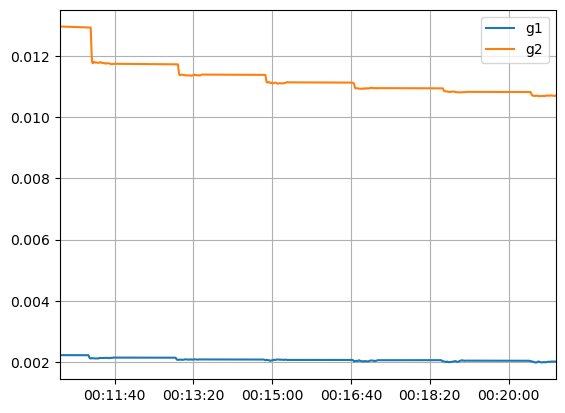

In [21]:
axe = data.plot()
axe.grid()

In [22]:
data.values

array([[0.00222966, 0.01295608],
       [0.00222964, 0.01295586],
       [0.00222962, 0.01295563],
       ...,
       [0.00202031, 0.01069458],
       [0.0020203 , 0.01069684],
       [0.00202029, 0.01069854]])

In [23]:
x_exp = solver.measurands(data.values, x0=[700, 30])

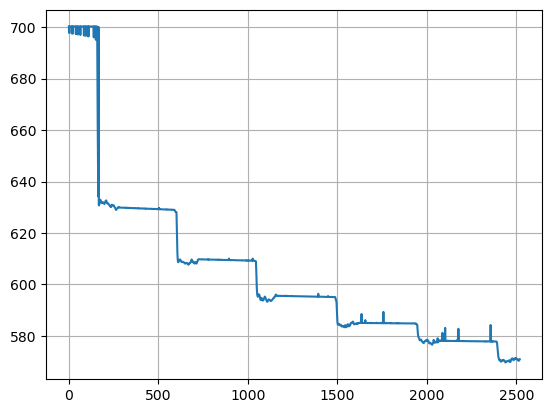

In [24]:
fig, axe = plt.subplots()
axe.plot(x_exp[:,0])
axe.grid()

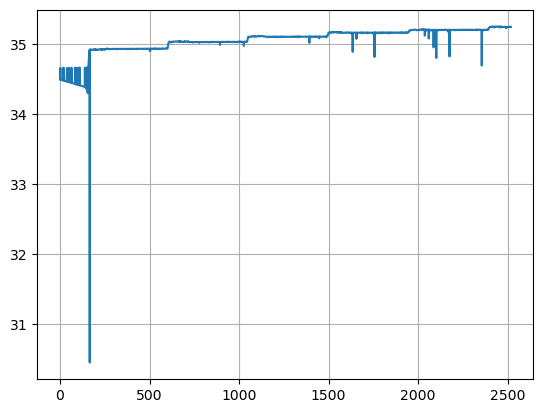

In [25]:
fig, axe = plt.subplots()
axe.plot(x_exp[:,1])
axe.grid()